In [33]:
import pandas as pd
import os
import smarts_cerebellum.globals as gl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
dti = dti[dti.isPatient == 1] # just patients

# behavioural metrics
behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t')
behav.rename(columns = {'subj_name': 'subj_id', 'week': 'Week'}, inplace = True)
behav['subj_id'] = behav['subj_id'].str.strip()
behav.loc[behav['Week']==1, 'Week'] = 0

# cerebellum GMV
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
cerebel = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
cerebel = cerebel[cerebel.isPatient==1] # just patients
cerebel = cerebel[cerebel.regionname.isin(regions)]
cerebel['hemisphere'] = cerebel.regionname.str[2]

/localscratch/tmp/ipykernel_40120/1506670006.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


Note that we have fewer subjects that have BOTH DTI and T1 with behavioural data. So we have some subjs in the DTI dataframe that Jing sent that don't have FaMap images (for some weeks).

In [34]:
print("subjs with behavioural and DTI")
for week in gl.weeks:
    behav_subjs = set(behav.loc[behav.Week == week, 'subj_id'])
    dti_subjs = set(dti.loc[dti.Week == week, 'subj_id'])
    subjs = behav_subjs & dti_subjs # A intersection B
    print(f'week {week}: n = {len(subjs)}')

subjs with behavioural and DTI
week 0: n = 11
week 4: n = 19
week 12: n = 17
week 24: n = 17
week 52: n = 13


# Axial diffusivity ($\lambda_1$)

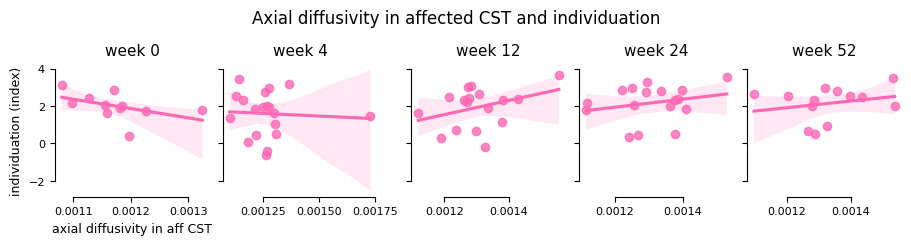

**Pearson R and p-value for AD in affected CST and individuation** 

week 0: r = -0.46622328992462597, p-value = 0.14833345218363342
week 4: r = -0.06338230513914662, p-value = 0.7965769915484524
week 12: r = 0.35387501906772095, p-value = 0.163465605336976
week 24: r = 0.23640631389453884, p-value = 0.36096502670587133
week 52: r = 0.23982607614290122, p-value = 0.42999577398761457


In [35]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'indivIdx', data = behav_dti_plot, ax = ax, color = 'hotpink')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (index)")
axs[0].set_xlabel(f"axial diffusivity in aff CST")
fig.suptitle(f"Axial diffusivity in affected CST and individuation", y = 1.15)

sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for AD in affected CST and individuation** \n")
for week in gl.weeks:
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['indivIdx'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


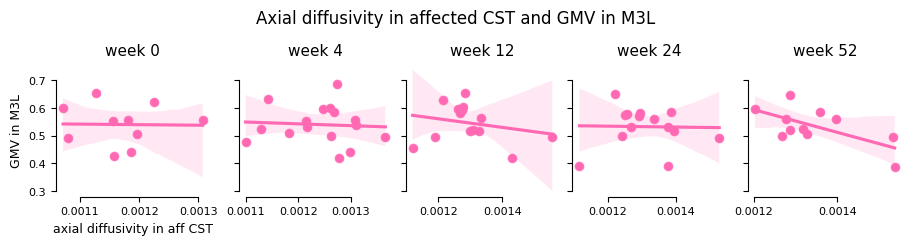

**Pearson R and p-value for AD in affected CST and GMV in M3L (cerebellum)** 

week 0: r = -0.018168628067247755, p-value = 0.9602692429195276
week 4: r = -0.06819614946058553, p-value = 0.8018541029168749
week 12: r = -0.2379550092221426, p-value = 0.41267053332510195
week 24: r = -0.022229730806200963, p-value = 0.9398729561706729
week 52: r = -0.650268893015177, p-value = 0.03029443174591395


In [36]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    ax = axs[i]
    sns.scatterplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'hotpink')
    sns.regplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'hotpink')
    #sns.scatterplot(x = 'right_norm', y = 'indiv_norm', data =aff_df, ax = ax, edgecolor = None,  legend = False)

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("GMV in M3L")
axs[0].set_xlabel(f"axial diffusivity in aff CST")
fig.suptitle(f"Axial diffusivity in affected CST and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for AD in affected CST and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_dti_plot['mean_dti'], cerebel_dti_plot['mean_cerebel'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

# Radial diffusivity ($\frac{\lambda_2 + \lambda_3}{2}$)

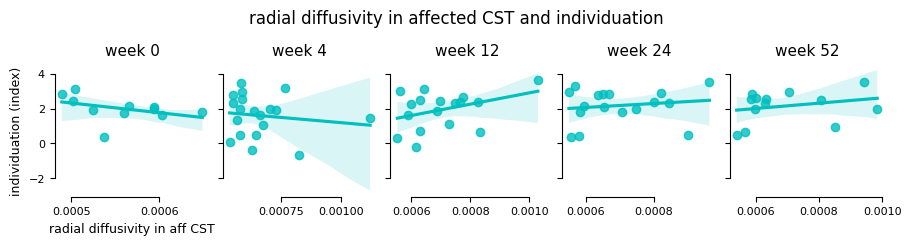

**Pearson R and p-value for RD in affected CST and individuation** 

week 0: r = -0.39417949106859246, p-value = 0.2303011441331447
week 4: r = -0.13884001896940296, p-value = 0.5708085219536666
week 12: r = 0.37319099149209367, p-value = 0.1400983538525579
week 24: r = 0.1503478574930411, p-value = 0.5646336548129467
week 52: r = 0.25104559486506234, p-value = 0.40805152906152053


In [37]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    #sns.scatterplot(x = 'mean', y = 'indivIdx', data = behav_dti_plot, ax = ax, color = 'hotpink')
    sns.regplot(x = 'mean', y = 'indivIdx', data = behav_dti_plot, ax = ax, color = 'c')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (index)")
axs[0].set_xlabel(f"radial diffusivity in aff CST")
fig.suptitle(f"radial diffusivity in affected CST and individuation", y = 1.15)

sns.despine(trim = True)
plt.show()

print("**Pearson R and p-value for RD in affected CST and individuation** \n")
for week in gl.weeks:
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['indivIdx'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


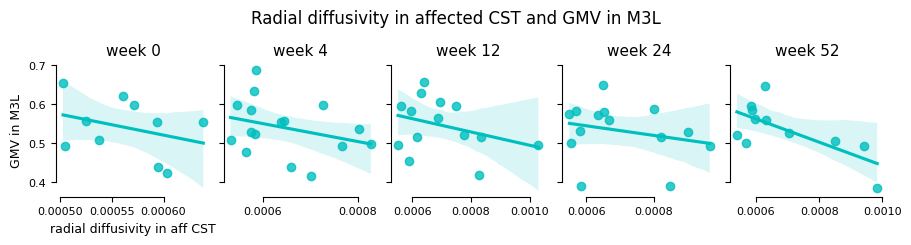

**Pearson R and p-value for RD in affected CST and GMV in M3L (cerebellum)** 

week 0: r = -0.3202308874351389, p-value = 0.3670181895817585
week 4: r = -0.3078816803716893, p-value = 0.24601537586903488
week 12: r = -0.33066110869021825, p-value = 0.24820445148445214
week 24: r = -0.2376673902267099, p-value = 0.4132524967351025
week 52: r = -0.6938365173181541, p-value = 0.017871067331064888


In [38]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    ax = axs[i]
    #sns.scatterplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'hotpink')
    sns.regplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'c')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("GMV in M3L")
axs[0].set_xlabel(f"radial diffusivity in aff CST")
fig.suptitle(f"Radial diffusivity in affected CST and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for RD in affected CST and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_dti_plot['mean_dti'], cerebel_dti_plot['mean_cerebel'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

# Fractional anisotropy

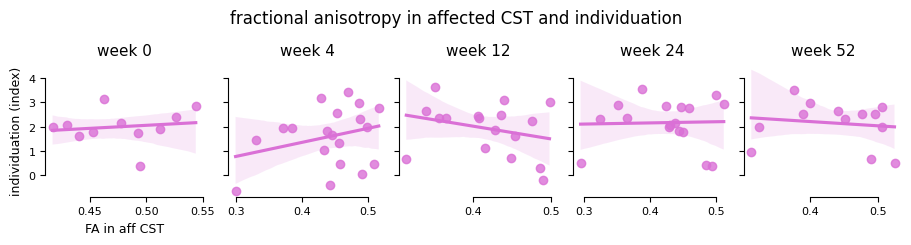

**Pearson R and p-value for FA in affected CST and individuation** 

week 0: r = 0.14415357678669394, p-value = 0.6723910480384523
week 4: r = 0.2879450718961178, p-value = 0.23191498463829954
week 12: r = -0.2792523474709983, p-value = 0.2777160573550492
week 24: r = 0.03075721283200969, p-value = 0.9067153742259405
week 52: r = -0.13601917385245937, p-value = 0.6577094388291748


In [39]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'indivIdx', data = behav_dti_plot, ax = ax, color = 'orchid')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (index)")
axs[0].set_xlabel(f"FA in aff CST")
fig.suptitle(f"fractional anisotropy in affected CST and individuation", y = 1.15)

sns.despine(trim = True)
plt.show()


print("**Pearson R and p-value for FA in affected CST and individuation** \n")
for week in gl.weeks:
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['indivIdx'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')


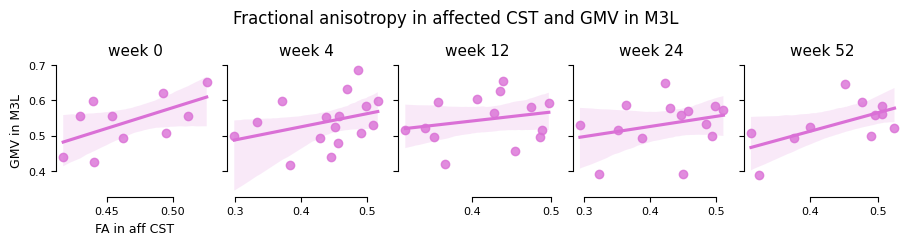

**Pearson R and p-value for FA in affected CST and GMV in M3L (cerebellum)** 

week 0: r = 0.5846025027327517, p-value = 0.0759039072919623
week 4: r = 0.33557543800061784, p-value = 0.2038514757491978
week 12: r = 0.22771520207679247, p-value = 0.43364750316616524
week 24: r = 0.2726929242663397, p-value = 0.34555705666086695
week 52: r = 0.5947107364681079, p-value = 0.05363085998962196


In [40]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    ax = axs[i]
    sns.regplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'orchid')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("GMV in M3L")
axs[0].set_xlabel(f"FA in aff CST")
fig.suptitle(f"Fractional anisotropy in affected CST and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()

print("**Pearson R and p-value for FA in affected CST and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_dti_plot['mean_dti'], cerebel_dti_plot['mean_cerebel'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

# Recreating Jing's results 
(see text above Fig. 6; https://pmc.ncbi.nlm.nih.gov/articles/PMC5547267/#F0006)

In [41]:
# behavioural metrics
behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t')
behav.rename(columns = {'subj_name': 'subj_id', 'week': 'Week'}, inplace = True)
behav['subj_id'] = behav['subj_id'].str.strip()
behav.loc[behav['Week']==1, 'Week'] = 0


### Fig 6.B
lesion volume in hand ROI (GM ROI) significantly correlated with individuation index at all time points.

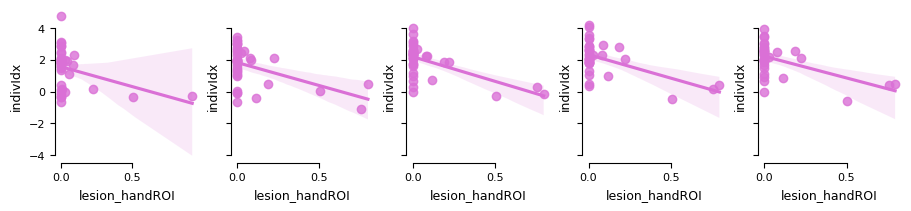

week 0: r = -0.3440185841321724, p-value = 0.0344417451267368
week 4: r = -0.47249672757747624, p-value = 0.0027410430983325243
week 12: r = -0.5794332268157916, p-value = 0.00011098508404983359
week 24: r = -0.5488150591004066, p-value = 0.00035995794803776726
week 52: r = -0.5366052893986166, p-value = 0.0012849646583911203


In [42]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)

for i, week in enumerate(gl.weeks):
    behav_week = behav[behav.Week == week]
    behav_week = behav_week[['lesion_handROI', 'indivIdx']].apply(pd.to_numeric, errors='coerce').dropna() # make all values numeric

    ax = axs[i]
    sns.regplot(x = 'lesion_handROI', y = 'indivIdx', data = behav_week, ax = ax, color = 'orchid')

sns.despine(trim = True)
plt.show()

for week in gl.weeks:
    behav_week = behav[behav.Week == week]
    behav_week = behav_week[['lesion_handROI', 'indivIdx']].apply(pd.to_numeric, errors='coerce').dropna() # make all values numeric

    r_stat, p_stat = stats.pearsonr(behav_week['lesion_handROI'], behav_week['indivIdx'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

### Fig 6.C
lesion volume in CST (WM ROI) significantly correlated with individuation index at all time points.

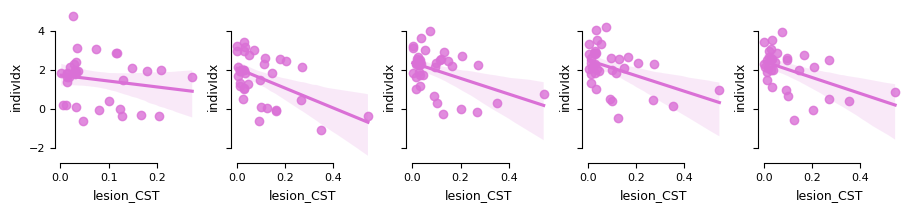

week 0: r = -0.17461577148111226, p-value = 0.3310964369767178
week 4: r = -0.4930278973161893, p-value = 0.0019328397302644353
week 12: r = -0.44055072772299564, p-value = 0.00635414456998974
week 24: r = -0.4316128062155138, p-value = 0.008578268946154826
week 52: r = -0.4702622545998463, p-value = 0.006607563403311951


In [43]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)

for i, week in enumerate(gl.weeks):
    behav_week = behav[behav.Week == week]
    behav_week = behav_week[['lesion_CST', 'indivIdx']].apply(pd.to_numeric, errors='coerce').dropna() # make all values numeric

    ax = axs[i]
    sns.regplot(x = 'lesion_CST', y = 'indivIdx', data = behav_week, ax = ax, color = 'orchid')

sns.despine(trim = True)
plt.show()

for week in gl.weeks:
    behav_week = behav[behav.Week == week]
    behav_week = behav_week[['lesion_CST', 'indivIdx']].apply(pd.to_numeric, errors='coerce').dropna() # make all values numeric

    r_stat, p_stat = stats.pearsonr(behav_week['lesion_CST'], behav_week['indivIdx'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')